# Analisis Aliran Trafik Enam Router
## Gauss-Jordan dan Gauss-Seidel

Notebook ini membahas penyelesaian **Sistem Persamaan Linier (SPL)** pada studi kasus aliran trafik enam router menggunakan dua metode:

1. **Gauss-Jordan** sebagai metode langsung.
2. **Gauss-Seidel** sebagai metode iteratif.

> **Catatan penting:** topologi, pembagian trafik, dan angka trafik pada studi kasus ini merupakan **asumsi kelompok**. Data tersebut bukan angka yang diberikan langsung pada brief tugas.

Solusi yang akan diperoleh adalah total trafik yang diproses oleh masing-masing router, dalam **paket/detik**.


## 1. Skenario jaringan

Enam router membentuk topologi cincin:

```text
        R1 ───── R2
      /            \
     R6            R3
      \            /
        R5 ───── R4
```

Setiap router menerima:

- trafik eksternal dari luar jaringan, $b_i$,
- 25% trafik dari tetangga di sebelah kiri,
- 25% trafik dari tetangga di sebelah kanan.

Setiap router kemudian membagi total trafik yang diprosesnya menjadi:

- **25%** ke tetangga pertama,
- **25%** ke tetangga kedua,
- **50%** keluar jaringan.

Jadi total keluaran setiap router tetap 100% dari trafik yang diproses.

### Trafik eksternal

| Router | Trafik eksternal $b_i$ |
|---|---:|
| R1 | 20 |
| R2 | 60 |
| R3 | 70 |
| R4 | 80 |
| R5 | 90 |
| R6 | 130 |

Semua nilai bersatuan **paket/detik**.


## 2. Apa arti variabel $x_i$?

Variabel

$$
x_i
$$

**bukan** trafik pada satu link tertentu.

$x_i$ adalah **total laju trafik yang diproses router $R_i$**.

Contohnya, jika akhirnya diperoleh

$$
x_1 = 100,
$$

artinya router R1 memproses total **100 paket/detik**.

Karena aturan pembagiannya 25%-25%-50%, maka dari 100 paket/detik tersebut:

- 25 paket/detik dikirim ke R2,
- 25 paket/detik dikirim ke R6,
- 50 paket/detik keluar jaringan.

Inilah alasan satu paket bisa ikut terhitung di lebih dari satu $x_i$: paket dapat melewati beberapa router sebelum akhirnya keluar dari jaringan.


## 3. Membentuk Sistem Persamaan Linier

Pada kondisi tunak digunakan prinsip **konservasi aliran**:

$$
\text{total masuk} = \text{total keluar}.
$$

Untuk router $R_i$:

$$
b_i + \frac14 x_{i-1} + \frac14 x_{i+1} = x_i.
$$

Karena jaringan berbentuk cincin:

- tetangga R1 adalah R6 dan R2,
- tetangga R6 adalah R5 dan R1.

### Contoh pada R1

Trafik eksternal yang masuk ke R1 adalah 20. R1 juga menerima 25% trafik dari R2 dan 25% dari R6:

$$
20 + \frac14x_2 + \frac14x_6 = x_1.
$$

Kalikan seluruh persamaan dengan 4 agar tidak perlu bekerja dengan banyak pecahan:

$$
4x_1 - x_2 - x_6 = 80.
$$

Dengan cara yang sama diperoleh:

$$
\begin{aligned}
4x_1-x_2-x_6 &= 80\\
-x_1+4x_2-x_3 &= 240\\
-x_2+4x_3-x_4 &= 280\\
-x_3+4x_4-x_5 &= 320\\
-x_4+4x_5-x_6 &= 360\\
-x_1-x_5+4x_6 &= 520
\end{aligned}
$$


### Kenapa ruas kanan menjadi 80, 240, 280, ...?

Trafik eksternal aslinya adalah

$$
b_{\text{ext}} =
\begin{bmatrix}
20\\60\\70\\80\\90\\130
\end{bmatrix}.
$$

Karena setiap persamaan tadi **dikalikan 4**, ruas kanannya juga dikalikan 4:

$$
c = 4b_{\text{ext}}
=
\begin{bmatrix}
80\\240\\280\\320\\360\\520
\end{bmatrix}.
$$

Jadi penting membedakan dua hal:

- `b_ext = [20, 60, 70, 80, 90, 130]` adalah **trafik eksternal sebenarnya**.
- `c = [80, 240, 280, 320, 360, 520]` adalah **ruas kanan SPL setelah persamaan dikali 4**.

Dalam notasi generik $Ax=b$, matriks dan ruas kanan yang dipakai program adalah $A=M$ dan $b=c$.


## 4. Bentuk matriks

Sistem tersebut dapat ditulis sebagai

$$
M\mathbf{x}=\mathbf{c},
$$

dengan

$$
\mathbf{x}=
\begin{bmatrix}
x_1\\x_2\\x_3\\x_4\\x_5\\x_6
\end{bmatrix},
$$

dan matriks koefisien

$$
M=
\begin{bmatrix}
4&-1&0&0&0&-1\\
-1&4&-1&0&0&0\\
0&-1&4&-1&0&0\\
0&0&-1&4&-1&0\\
0&0&0&-1&4&-1\\
-1&0&0&0&-1&4
\end{bmatrix}.
$$

Matriks ini **dominan diagonal secara ketat** karena pada setiap baris:

$$
|m_{ii}|=4 > 1+1=2.
$$

Sifat ini penting terutama untuk Gauss-Seidel karena membantu menjamin konvergensi pada sistem ini.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matriks koefisien
A = np.array([
    [ 4, -1,  0,  0,  0, -1],
    [-1,  4, -1,  0,  0,  0],
    [ 0, -1,  4, -1,  0,  0],
    [ 0,  0, -1,  4, -1,  0],
    [ 0,  0,  0, -1,  4, -1],
    [-1,  0,  0,  0, -1,  4]
], dtype=float)

# Trafik eksternal sebenarnya
b_ext = np.array([20, 60, 70, 80, 90, 130], dtype=float)

# Ruas kanan SPL setelah semua persamaan dikali 4
b = 4 * b_ext

np.set_printoptions(precision=6, suppress=True)

print("Trafik eksternal b_ext:")
print(b_ext)

print("\nRuas kanan SPL b = 4 * b_ext:")
print(b)


Trafik eksternal b_ext:
[ 20.  60.  70.  80.  90. 130.]

Ruas kanan SPL b = 4 * b_ext:
[ 200.  600.  700.  800.  900. 1300.]


# 5. Metode Gauss-Jordan

Gauss-Jordan adalah **metode langsung**.

Matriks $A$ dan vektor $b$ digabung menjadi matriks augmented:

$$
[A\mid b].
$$

Untuk setiap kolom:

1. pilih pivot,
2. tukar baris bila diperlukan,
3. normalkan baris pivot agar pivot menjadi 1,
4. nolkan semua elemen lain pada kolom pivot.

Target akhirnya adalah

$$
[I\mid x].
$$

Karena bagian kiri sudah menjadi matriks identitas, solusi dapat langsung dibaca dari kolom paling kanan.

> Enam tahap pivot Gauss-Jordan **bukan enam iterasi pendekatan**. Setiap tahap adalah operasi eliminasi yang menghasilkan sistem baru yang tetap ekuivalen dengan sistem sebelumnya.


In [ ]:
def gauss_jordan(A, b):
    n = len(b)
    aug = np.column_stack((A, b)).astype(float)

    history = []

    for k in range(n):
        # Partial pivoting:
        # cari nilai absolut terbesar pada kolom k mulai dari baris k
        pivot_row = k + np.argmax(np.abs(aug[k:, k]))

        if np.isclose(aug[pivot_row, k], 0):
            raise ValueError("Tidak ada solusi tunggal: pivot nol")

        # Tukar baris bila diperlukan
        aug[[k, pivot_row]] = aug[[pivot_row, k]]

        # Normalisasi pivot menjadi 1
        pivot = aug[k, k]
        aug[k] = aug[k] / pivot

        # Nolkan seluruh elemen lain pada kolom pivot
        for i in range(n):
            if i != k:
                faktor = aug[i, k]
                aug[i] = aug[i] - faktor * aug[k]

        history.append(aug.copy())

        print(f"\n===== Setelah pivot ke-{k + 1} =====")
        print(aug)

    return aug[:, -1], history


x_gj, history_gj = gauss_jordan(A, b)

print("\nSolusi Gauss-Jordan:")
for i, nilai in enumerate(x_gj, start=1):
    print(f"x{i} = {nilai:.10f} paket/detik")



===== Setelah pivot ke-1 =====
[[   1.    -0.1   -0.1   -0.1   -0.1   -0.1   20. ]
 [   0.     9.9   -1.1   -1.1   -1.1   -1.1  620. ]
 [   0.    -1.1    9.9   -1.1   -1.1   -1.1  720. ]
 [   0.    -1.1   -1.1    9.9   -1.1   -1.1  820. ]
 [   0.    -1.1   -1.1   -1.1    9.9   -1.1  920. ]
 [   0.    -1.1   -1.1   -1.1   -1.1    9.9 1320. ]]

===== Setelah pivot ke-2 =====
[[   1.          0.         -0.111111   -0.111111   -0.111111   -0.111111
    26.262626]
 [   0.          1.         -0.111111   -0.111111   -0.111111   -0.111111
    62.626263]
 [   0.          0.          9.777778   -1.222222   -1.222222   -1.222222
   788.888889]
 [   0.          0.         -1.222222    9.777778   -1.222222   -1.222222
   888.888889]
 [   0.          0.         -1.222222   -1.222222    9.777778   -1.222222
   988.888889]
 [   0.          0.         -1.222222   -1.222222   -1.222222    9.777778
  1388.888889]]

===== Setelah pivot ke-3 =====
[[   1.          0.          0.         -0.125      -0.1

## Contoh membaca eliminasi pertama

Matriks awal memiliki baris pertama

$$
[4,\,-1,\,0,\,0,\,0,\,-1\mid80].
$$

Pivot pertama adalah 4, sehingga:

$$
R_1 \leftarrow \frac{R_1}{4}.
$$

Hasilnya:

$$
[1,\,-\tfrac14,\,0,\,0,\,0,\,-\tfrac14\mid20].
$$

Pada baris kedua koefisien kolom pertama adalah $-1$, sehingga:

$$
R_2 \leftarrow R_2 + R_1.
$$

Ruas kanannya berubah dari

$$
240 \rightarrow 240+20=260.
$$

Gauss-Jordan melakukan proses serupa sampai keenam kolom variabel membentuk matriks identitas.


# 6. Metode Gauss-Seidel

Gauss-Seidel adalah **metode iteratif**. Berbeda dengan Gauss-Jordan, metode ini memulai dari tebakan awal lalu mendekati solusi sedikit demi sedikit.

Dari sistem persamaan, setiap variabel diisolasi:

$$
\begin{aligned}
x_1^{(k+1)} &= 20+\frac14(x_2^{(k)}+x_6^{(k)})\\
x_2^{(k+1)} &= 60+\frac14(x_1^{(k+1)}+x_3^{(k)})\\
x_3^{(k+1)} &= 70+\frac14(x_2^{(k+1)}+x_4^{(k)})\\
x_4^{(k+1)} &= 80+\frac14(x_3^{(k+1)}+x_5^{(k)})\\
x_5^{(k+1)} &= 90+\frac14(x_4^{(k+1)}+x_6^{(k)})\\
x_6^{(k+1)} &= 130+\frac14(x_1^{(k+1)}+x_5^{(k+1)})
\end{aligned}
$$

Hal penting pada Gauss-Seidel:

> Begitu nilai baru sudah tersedia pada iterasi yang sedang berjalan, nilai itu **langsung digunakan** untuk menghitung variabel berikutnya.

Misalnya dari tebakan awal

$$
x^{(0)}=(0,0,0,0,0,0),
$$

maka pada iterasi pertama:

$$
x_1^{(1)} = 20,
$$

lalu ketika menghitung $x_2^{(1)}$, program langsung memakai $x_1^{(1)}=20$, bukan lagi $x_1^{(0)}=0$.


In [ ]:
def gauss_seidel(A, b, x0=None, tol=1e-8, max_iter=10000):
    n = len(b)

    if x0 is None:
        x = np.zeros(n, dtype=float)
    else:
        x = np.array(x0, dtype=float)

    history = [x.copy()]

    # Residual infinity: nilai absolut terbesar dari Ax-b
    residual = np.linalg.norm(A @ x - b, ord=np.inf)
    residual_history = [residual]

    # Perubahan antariterasi (dicatat, tapi bukan stopping criterion utama)
    delta_history = [np.nan]

    print(f"Iterasi 0: {x}")
    print(f"Residual infinity = {residual:.10e}")

    for it in range(1, max_iter + 1):
        x_lama = x.copy()

        for i in range(n):
            if np.isclose(A[i, i], 0):
                raise ValueError(f"Elemen diagonal A[{i},{i}] bernilai nol")

            # Nilai baru untuk variabel sebelum i
            sigma_baru = np.dot(A[i, :i], x[:i])

            # Nilai lama untuk variabel setelah i
            sigma_lama = np.dot(A[i, i+1:], x_lama[i+1:])

            x[i] = (b[i] - sigma_baru - sigma_lama) / A[i, i]

        delta = np.linalg.norm(x - x_lama, ord=np.inf)
        residual = np.linalg.norm(A @ x - b, ord=np.inf)

        history.append(x.copy())
        delta_history.append(delta)
        residual_history.append(residual)

        print(
            f"Iterasi {it:2d}: {x} | "
            f"residual_inf = {residual:.10e} | "
            f"delta_inf = {delta:.10e}"
        )

        # Sesuai pembahasan laporan:
        # berhenti ketika residual infinity <= toleransi
        if residual <= tol:
            print(f"\nKonvergen pada iterasi ke-{it}")
            return x, history, residual_history, delta_history

    print("\nPeringatan: belum konvergen sampai max_iter")
    return x, history, residual_history, delta_history


x_gs, history_gs, residual_gs, delta_gs = gauss_seidel(
    A,
    b,
    x0=np.zeros(6),
    tol=1e-8,
    max_iter=10000
)

print("\nSolusi Gauss-Seidel:")
for i, nilai in enumerate(x_gs, start=1):
    print(f"x{i} = {nilai:.10f} paket/detik")


Iterasi 0: [0. 0. 0. 0. 0. 0.]
Residual infinity = 1.3000000000e+03
Iterasi  1: [ 20.      62.      78.2     96.02   115.622  167.1842] | residual_inf = 5.1902620000e+02 | delta_inf = 1.6718420000e+02
Iterasi  2: [ 71.90262  112.892882 126.36217  139.396387 151.773826 190.232789] | residual_inf = 2.0163185390e+02 | delta_inf = 5.1902620000e+01
Iterasi  3: [ 92.065805 129.983098 140.34519  150.440071 160.306695 197.314086] | residual_inf = 5.7731086385e+01 | delta_inf = 2.0163185390e+01
Iterasi  4: [ 97.838914 134.624496 144.052426 153.413662 162.724358 199.265386] | residual_inf = 1.5691187211e+01 | delta_inf = 5.7731086385e+00
Iterasi  5: [ 99.408033 135.886386 145.069782 154.235395 163.386498 199.798609] | residual_inf = 4.2963436448e+00 | delta_inf = 1.5691187211e+00
Iterasi  6: [ 99.837667 136.232795 145.349096 154.460467 163.567863 199.944789] | residual_inf = 1.1783394947e+00 | delta_inf = 4.2963436448e-01
Iterasi  7: [ 99.955501 136.327772 145.425639 154.522156 163.617586 199.98

## Contoh dua iterasi pertama Gauss-Seidel

Dengan $x^{(0)}=0$, iterasi pertama menghasilkan kira-kira:

$$
x^{(1)}=
(20,\ 65,\ 86.25,\ 101.5625,\ 115.390625,\ 163.84765625).
$$

Iterasi kedua menggunakan hasil iterasi pertama dan menghasilkan kira-kira:

$$
x^{(2)}=
(77.211914,\ 100.865479,\ 120.606995,\ 138.999405,\ 165.711765,\ 190.730920).
$$

Nilainya kemudian terus bergerak menuju:

$$
(100,\ 120,\ 140,\ 160,\ 180,\ 200).
$$


# 7. Verifikasi hasil

Solusi yang benar seharusnya memenuhi kembali persamaan awal.

Untuk R1:

$$
20 + 0.25x_2 + 0.25x_6
=
20+0.25(120)+0.25(200)
=
100.
$$

Nilai tersebut sama dengan $x_1=100$.

Di sisi keluaran R1:

$$
0.25(100)+0.25(100)+0.50(100)=100.
$$

Jadi **total masuk = total keluar**.


In [13]:
# Verifikasi konservasi aliran setiap router
x = x_gj

neighbors = [
    (5, 1),  # R1 menerima dari R6 dan R2
    (0, 2),  # R2 dari R1 dan R3
    (1, 3),  # R3 dari R2 dan R4
    (2, 4),  # R4 dari R3 dan R5
    (3, 5),  # R5 dari R4 dan R6
    (4, 0),  # R6 dari R5 dan R1
]

print("Verifikasi konservasi aliran:\n")
print("Router | Eksternal | Dari tetangga 1 | Dari tetangga 2 | Total masuk | Total keluar")
print("-" * 90)

for i, (left, right) in enumerate(neighbors):
    dari_1 = 0.25 * x[left]
    dari_2 = 0.25 * x[right]
    total_masuk = b_ext[i] + dari_1 + dari_2
    total_keluar = x[i]

    print(
        f"R{i+1:<5} | "
        f"{b_ext[i]:9.2f} | "
        f"{dari_1:15.2f} | "
        f"{dari_2:15.2f} | "
        f"{total_masuk:11.2f} | "
        f"{total_keluar:12.2f}"
    )

print("\nPemeriksaan global:")
print("Total trafik eksternal masuk =", np.sum(b_ext))
print("Total trafik keluar jaringan =", 0.5 * np.sum(x))

residual_gj_final = np.linalg.norm(A @ x_gj - b, ord=np.inf)
residual_gs_final = np.linalg.norm(A @ x_gs - b, ord=np.inf)

print("\nResidual infinity akhir:")
print("Gauss-Jordan =", residual_gj_final)
print("Gauss-Seidel =", residual_gs_final)


Verifikasi konservasi aliran:

Router | Eksternal | Dari tetangga 1 | Dari tetangga 2 | Total masuk | Total keluar
------------------------------------------------------------------------------------------
R1     |     20.00 |           50.00 |           34.09 |      104.09 |       100.00
R2     |     60.00 |           25.00 |           36.36 |      121.36 |       136.36
R3     |     70.00 |           34.09 |           38.64 |      142.73 |       145.45
R4     |     80.00 |           36.36 |           40.91 |      157.27 |       154.55
R5     |     90.00 |           38.64 |           50.00 |      178.64 |       163.64
R6     |    130.00 |           40.91 |           25.00 |      195.91 |       200.00

Pemeriksaan global:
Total trafik eksternal masuk = 450.0
Total trafik keluar jaringan = 450.0

Residual infinity akhir:
Gauss-Jordan = 2.2737367544323206e-13
Gauss-Seidel = 4.370235728856642e-09


## Apa itu residual?

Residual adalah

$$
r = Ax-b.
$$

Residual mengukur **seberapa tidak cocok solusi yang sedang kita punya terhadap SPL asli**.

Norma infinity residual:

$$
\|r\|_\infty
=
\max_i |r_i|
$$

mengambil nilai absolut residual terbesar.

Ini berbeda dari:

- **toleransi**, yaitu batas yang kita tentukan sendiri, misalnya $10^{-8}$;
- **perubahan iterasi**, yaitu seberapa jauh $x^{(k)}$ berubah dari $x^{(k-1)}$;
- **galat solusi**, yaitu jarak terhadap solusi eksak yang sebenarnya.

Pada Gauss-Seidel di notebook ini, kondisi berhenti adalah:

$$
\|Ax^{(k)}-b\|_\infty \le 10^{-8}.
$$


# 8. Progress Gauss-Seidel per iterasi

Pada Gauss-Seidel, setiap iterasi benar-benar merupakan **pendekatan solusi baru**, sehingga perkembangan $x_1,\ldots,x_6$ dapat diplot langsung.


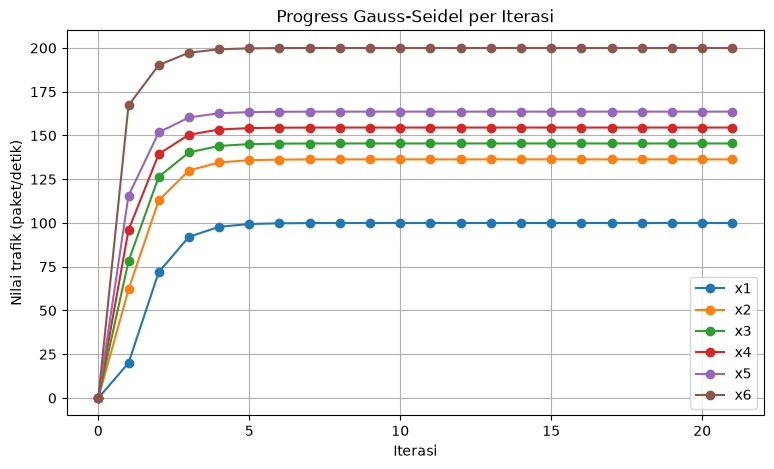

In [16]:
history_gs_array = np.array(history_gs)

plt.figure(figsize=(9, 5))

for j in range(history_gs_array.shape[1]):
    plt.plot(
        range(len(history_gs_array)),
        history_gs_array[:, j],
        marker="o",
        label=f"x{j+1}"
    )

plt.xlabel("Iterasi")
plt.ylabel("Nilai trafik (paket/detik)")
plt.title("Progress Gauss-Seidel per Iterasi")
plt.grid(True)
plt.legend()
plt.show()


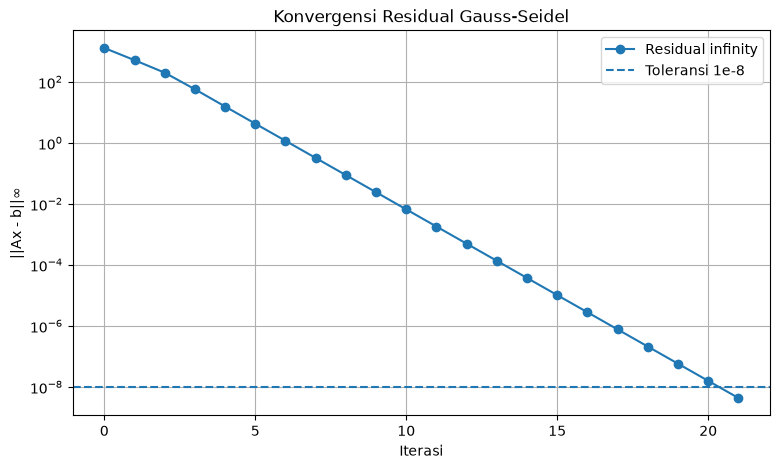

In [17]:
plt.figure(figsize=(9, 5))

plt.semilogy(
    range(len(residual_gs)),
    residual_gs,
    marker="o",
    label="Residual infinity"
)

plt.axhline(
    1e-8,
    linestyle="--",
    label="Toleransi 1e-8"
)

plt.xlabel("Iterasi")
plt.ylabel("||Ax - b||∞")
plt.title("Konvergensi Residual Gauss-Seidel")
plt.grid(True)
plt.legend()
plt.show()


# 9. Perbandingan akhir

| Aspek | Gauss-Jordan | Gauss-Seidel |
|---|---|---|
| Jenis | Metode langsung | Metode iteratif |
| Tebakan awal | Tidak perlu | Perlu |
| Progress | Tahap eliminasi/pivot | Pendekatan solusi per iterasi |
| Pada kasus ini | 6 pivot | Sekitar 21 iterasi untuk toleransi $10^{-8}$ |
| Konvergensi | Membutuhkan pivot yang valid | Dijamin pada kasus ini oleh dominansi diagonal ketat |
| Solusi | $(100,120,140,160,180,200)$ | Mendekati solusi yang sama |

Untuk sistem kecil ini, Gauss-Jordan sangat praktis. Gauss-Seidel menjadi menarik ketika sistem semakin besar, terutama untuk matriks yang sparse dan memiliki sifat yang menjamin konvergensi.


In [18]:
print("Perbandingan solusi:")
print("Gauss-Jordan :", x_gj)
print("Gauss-Seidel :", x_gs)
print("Selisih      :", np.abs(x_gj - x_gs))

print("\nResidual infinity:")
print("Gauss-Jordan :", np.linalg.norm(A @ x_gj - b, ord=np.inf))
print("Gauss-Seidel :", np.linalg.norm(A @ x_gs - b, ord=np.inf))

print("\nJumlah tahap:")
print("Gauss-Jordan :", len(history_gj), "pivot")
print("Gauss-Seidel :", len(history_gs) - 1, "iterasi")


Perbandingan solusi:
Gauss-Jordan : [100.       136.363636 145.454545 154.545455 163.636364 200.      ]
Gauss-Seidel : [100.       136.363636 145.454545 154.545455 163.636364 200.      ]
Selisih      : [0. 0. 0. 0. 0. 0.]

Residual infinity:
Gauss-Jordan : 2.2737367544323206e-13
Gauss-Seidel : 4.370235728856642e-09

Jumlah tahap:
Gauss-Jordan : 6 pivot
Gauss-Seidel : 21 iterasi
